In [1]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import *
import requests
from sklearn.metrics import *
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch.optim as optim
from CONSTANTS import *
from audioread.ffdec import ReadTimeoutError
from functions import *
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from API_KEYS import *
warnings.filterwarnings('ignore')

# Load all possible Data

Last one year

In [2]:
# df, coin = prices(COIN, period=LIMIT)
# df.sort_values('time', ascending=False, inplace=True)
# df

All Time Data

In [8]:
start = datetime.now()
end = datetime.strptime('01/01/2008', '%m/%d/%Y')
df, coin = prices(COIN, start=end, end=start)
df.sort_values('time', ascending=False, inplace=True)

,time,low,high,open,close,volume,change,pct_change
3555,2025-06-26,106978.72,108345.00,107400.22,107000.83,2094.992837,-399.39,-0.371871
3556,2025-06-25,105875.00,108206.00,106141.01,107400.22,7070.250498,1259.21,1.186356
3557,2025-06-24,104681.83,106366.29,105418.40,106141.00,5773.171996,722.60,0.685459
3558,2025-06-23,99677.07,106135.47,100996.87,105419.39,8904.624392,4422.52,4.378868
3559,2025-06-22,98225.01,103417.00,102160.36,100996.87,7872.258744,-1163.49,-1.138886
...,...,...,...,...,...,...,...,...
239,2015-07-24,276.43,291.52,277.23,289.12,7362.469083,11.89,4.288858
240,2015-07-23,276.28,279.75,277.96,277.39,5306.919575,-0.57,-0.205065
241,2015-07-22,275.01,278.54,277.33,277.89,4687.909383,0.56,0.201926
242,2015-07-21,276.85,281.27,279.96,277.32,4943.559434,-2.64,-0.942992


Incorporate FGI metrics

In [9]:
fgi = get_fgi_data(df)
df = pd.merge(df, fgi, left_on='time', right_on='timestamp', how='left')
df['timestamp'].fillna(pd.to_datetime('1970-01-01'), inplace=True)
val = df[df['value'].isna() == False]['value'].values[0] # Last known FGI value
fgiClassification = df[df['value_classification'].isna() == False]['value_classification'].values[0] # Last known FGI classification
df['value'].fillna(val, inplace=True)
df['value_classification'].fillna(fgiClassification, inplace=True)

,time,low,high,open,close,volume,change,pct_change,timestamp,value,value_classification
0,2025-06-26,106978.72,108345.00,107400.22,107000.83,2094.992837,-399.39,-0.371871,1970-01-01,48.0,Neutral
1,2025-06-25,105875.00,108206.00,106141.01,107400.22,7070.250498,1259.21,1.186356,2025-06-25,48.0,Neutral
2,2025-06-24,104681.83,106366.29,105418.40,106141.00,5773.171996,722.60,0.685459,2025-06-24,47.0,Neutral
3,2025-06-23,99677.07,106135.47,100996.87,105419.39,8904.624392,4422.52,4.378868,2025-06-23,37.0,Fear
4,2025-06-22,98225.01,103417.00,102160.36,100996.87,7872.258744,-1163.49,-1.138886,2025-06-22,40.0,Neutral
...,...,...,...,...,...,...,...,...,...,...,...
3637,2015-07-24,276.43,291.52,277.23,289.12,7362.469083,11.89,4.288858,1970-01-01,48.0,Neutral
3638,2015-07-23,276.28,279.75,277.96,277.39,5306.919575,-0.57,-0.205065,1970-01-01,48.0,Neutral
3639,2015-07-22,275.01,278.54,277.33,277.89,4687.909383,0.56,0.201926,1970-01-01,48.0,Neutral
3640,2015-07-21,276.85,281.27,279.96,277.32,4943.559434,-2.64,-0.942992,1970-01-01,48.0,Neutral


## Crypto market collector

# Steps to train LSTM to predict buy and sell



1.   Obtain additional metrics

* Moving averages (short-term and long-term)
* Relative Strength Index (RSI)
* Moving Average Convergence Divergence (MACD)
* Bollinger Bands
* Volume indicators

2.   Model Approaches

* Classification
  * label buys, sells, holds (1, -1, 0) based on market data
  * predict each label

* Regression
  * predict return over time
    * look at windows of time to find optimal profits
  * identify buy and sell periods



### Generate Metrics

In [10]:
# Short-term SMA (20 periods) and long-term SMA (50 periods)
df['SMA_20'] = df['close'].rolling(window=20).mean().fillna(method='bfill')
df['SMA_50'] = df['close'].rolling(window=50).mean().fillna(method='bfill')
df[f'SMA_{TEST_DAYS}'] = df['close'].rolling(window=TEST_DAYS).mean().fillna(method='bfill')

# Exponential Moving Averages (optional, can be used in place of or along with SMAs)
df['EMA_20'] = df['close'].ewm(span=20, adjust=False).mean().fillna(method='bfill')
df['EMA_50'] = df['close'].ewm(span=50, adjust=False).mean().fillna(method='bfill')
df['RSI'] = compute_rsi(df['close'], window=TEST_DAYS)

# Calculate the 12-period and 26-period EMA of the closing price
df['EMA_12'] = df['close'].ewm(span=12, adjust=False).mean()
df['EMA_26'] = df['close'].ewm(span=26, adjust=False).mean()
df['MACD'] = df['EMA_12'] - df['EMA_26']
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']

# Bollinger Bands
df['BB_Middle'] = df['SMA_20']  # Middle band is the 20-period SMA
df['BB_STD'] = df['close'].rolling(window=20).std().fillna(method='bfill')
df['BB_Upper'] = df['BB_Middle'] + 2 * df['BB_STD']
df['BB_Lower'] = df['BB_Middle'] - 2 * df['BB_STD']
df[f'Volume_MA_{TEST_DAYS}'] = df['volume'].rolling(window=TEST_DAYS).mean()

# Daily Return and On-Balance Volume (OBV)
df['daily_return'] = df['close'].pct_change()
df['direction'] = np.where(df['daily_return'] > 0, 1, -1)
df.loc[df['daily_return'].isna(), 'direction'] = 0
df['OBV'] = (df['volume'] * df['direction']).fillna(0).cumsum() # cumulative on balance volume
df.drop(columns=['daily_return', 'direction'], inplace=True)

,time,low,high,open,close,volume,change,pct_change,timestamp,value,...,EMA_26,MACD,MACD_Signal,MACD_Hist,BB_Middle,BB_STD,BB_Upper,BB_Lower,Volume_MA_7,OBV
0,2025-06-26,106978.72,108345.00,107400.22,107000.83,2094.992837,-399.39,-0.371871,1970-01-01,48.0,...,107000.830000,0.000000,0.000000,0.000000,105852.3030,2298.238954,110448.780908,101255.825092,NaN,0.000000e+00
1,2025-06-25,105875.00,108206.00,106141.01,107400.22,7070.250498,1259.21,1.186356,2025-06-25,48.0,...,107030.414444,31.860171,6.372034,25.488137,105852.3030,2298.238954,110448.780908,101255.825092,NaN,7.070250e+03
2,2025-06-24,104681.83,106366.29,105418.40,106141.00,5773.171996,722.60,0.685459,2025-06-24,47.0,...,106964.531893,-43.991834,-3.700739,-40.291094,105852.3030,2298.238954,110448.780908,101255.825092,NaN,1.297079e+03
3,2025-06-23,99677.07,106135.47,100996.87,105419.39,8904.624392,4422.52,4.378868,2025-06-23,37.0,...,106850.076938,-160.483042,-35.057200,-125.425842,105852.3030,2298.238954,110448.780908,101255.825092,NaN,-7.607546e+03
4,2025-06-22,98225.01,103417.00,102160.36,100996.87,7872.258744,-1163.49,-1.138886,2025-06-22,40.0,...,106416.506054,-602.715834,-148.588927,-454.126907,105852.3030,2298.238954,110448.780908,101255.825092,NaN,-1.547980e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3637,2015-07-24,276.43,291.52,277.23,289.12,7362.469083,11.89,4.288858,1970-01-01,48.0,...,275.731790,11.022946,11.627888,-0.604942,281.6625,10.125224,301.912949,261.412051,5397.937160,-3.759418e+06
3638,2015-07-23,276.28,279.75,277.96,277.39,5306.919575,-0.57,-0.205065,1970-01-01,48.0,...,275.854620,9.459387,11.194188,-1.734801,282.1850,9.580477,301.345955,263.024045,5421.928306,-3.764725e+06
3639,2015-07-22,275.01,278.54,277.33,277.89,4687.909383,0.56,0.201926,1970-01-01,48.0,...,276.005389,8.166463,10.588643,-2.422180,282.4800,9.337795,301.155590,263.804410,5345.414337,-3.760037e+06
3640,2015-07-21,276.85,281.27,279.96,277.32,4943.559434,-2.64,-0.942992,1970-01-01,48.0,...,276.102768,7.014953,9.873905,-2.858952,283.0885,8.508773,300.106046,266.070954,5228.512882,-3.764980e+06


### Plot the Bollinger Bands

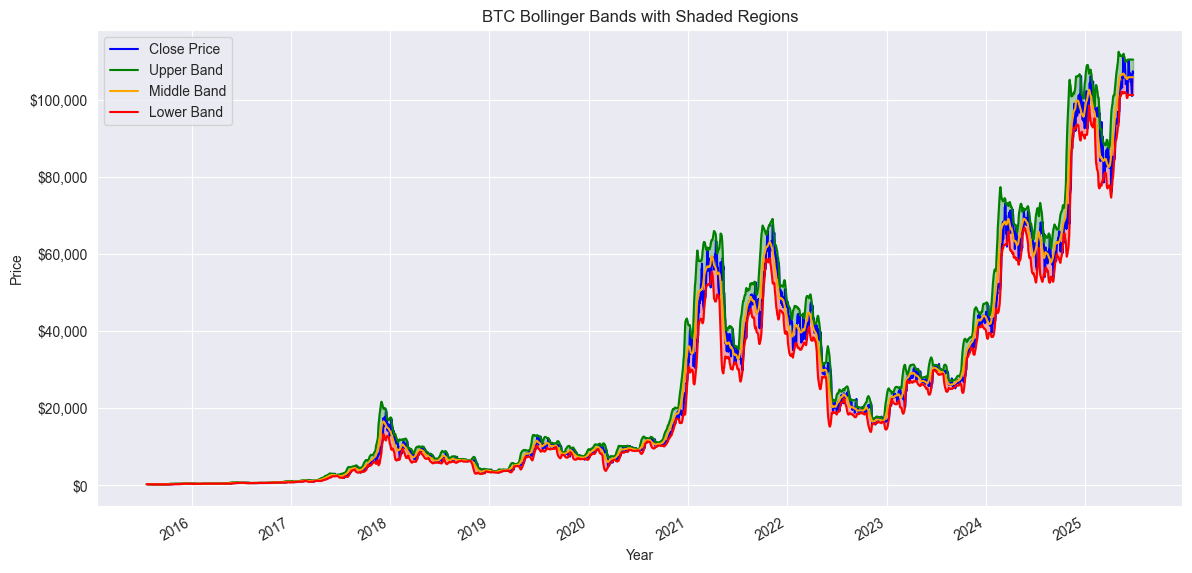

In [11]:
fig, ax = plt.subplots(figsize=(14, 7))

# Plot the price and Bollinger Bands
ax.plot(df['time'], df['close'], label='Close Price', color='blue')
ax.plot(df['time'], df['BB_Upper'], label='Upper Band', color='green')
ax.plot(df['time'], df['BB_Middle'], label='Middle Band', color='orange')
ax.plot(df['time'], df['BB_Lower'], label='Lower Band', color='red')
ax.fill_between(df['time'], df['BB_Upper'], df['BB_Middle'], color='green', alpha=0.3)
ax.fill_between(df['time'], df['BB_Middle'], df['BB_Lower'], color='red', alpha=0.3)

ax.set_xlabel('Year')
ax.set_ylabel('Price')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title(f'{COIN} Bollinger Bands with Shaded Regions')
ax.legend()
ax.grid(True)

fig.autofmt_xdate()
if not os.path.exists('plots'):
    os.makedirs('plots')
plt.savefig(f'plots/{COIN}_Bollinger_Bands.png')
try:
    df.set_index(df['time'], inplace=True, drop=True)
    df.drop('time', axis=1, inplace=True)
except:
    pass
df.to_csv(fullDataPath(coin), index=True)